In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nltk.sentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np


path = "Amazon_Unlocked_Mobile.csv"

# Preprocesamiento

In [7]:
df1 = pd.read_csv(path)
df1 = df1.dropna(subset=["Reviews"]) 
Rating = df1["Rating"]
Reviews = df1["Reviews"]

def positivo_negativo(rating):
    return [1 if r >= 4 else 0 for r in rating]
df1["Nuevo Rating"] = positivo_negativo(Rating)

def reviewN(reviews):
    # TfidfVectorizer convierte texto en una matriz de características numéricas
    # donde cada palabra tiene un peso (TF-IDF) que refleja su importancia en el documento
    vectorizer = TfidfVectorizer()
    
    # Transformación del texto a representación numérica
    # fit_transform hace dos cosas:
    # Aprende el vocabulario
    # Transforma las reviews en una matriz sparse
    # El resultado es una matriz donde:
    # Cada fila representa una review
    # Cada columna representa una palabra del vocabulario
    # Cada celda contiene el valor TF-IDF de esa palabra en esa review
    tfidf_matrix = vectorizer.fit_transform(reviews)
    
    # Cálculo del valor numérico promedio por review
    # mean(axis=1) calcula el promedio de los valores TF-IDF para cada review (por fila)
    # Esto da un solo valor numérico que representa la "importancia promedio" de las palabras en cada review
    # getA1() convierte el resultado de formato matriz numpy a un array unidimensional
    numeric_values = tfidf_matrix.mean(axis=1).getA1()
    return numeric_values
df1["Review Numerico"] = reviewN(Reviews)
df1.reset_index(drop=True, inplace=True)
df1

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078
...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037
413768,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,I returned it because it did not meet my needs...,0.0,0,0.000053


In [8]:
#Se descarga una libreria extra (en caso de no contar con ella)
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\eduar\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [9]:
#Se trabaja con sentiment Analyzer para diferenciar reviews positivas, negativas y neutras con un score
sia = SentimentIntensityAnalyzer()
results = {}

for row in df1.iterrows():
    text = row[1]["Reviews"]
    score = sia.polarity_scores(text)
    results[row[0]] = score

sentiment_score = pd.DataFrame(results).T

sentiment_score

,neg,neu,pos,compound
0,0.015,0.796,0.189,0.8783
1,0.072,0.597,0.331,0.9231
2,0.000,0.238,0.762,0.4927
3,0.000,0.500,0.500,0.9185
4,0.038,0.897,0.065,0.2942
...,...,...,...,...
413765,0.000,0.268,0.732,0.8481
413766,0.000,0.000,1.000,0.2960
413767,0.285,0.715,0.000,-0.3382
413768,0.000,0.806,0.194,0.5927


In [10]:
#Se agrega un label al index

sentiment_score.index.name = 'id'
sentiment_score

,neg,neu,pos,compound
id,,,,
0,0.015,0.796,0.189,0.8783
1,0.072,0.597,0.331,0.9231
2,0.000,0.238,0.762,0.4927
3,0.000,0.500,0.500,0.9185
4,0.038,0.897,0.065,0.2942
...,...,...,...,...
413765,0.000,0.268,0.732,0.8481
413766,0.000,0.000,1.000,0.2960
413767,0.285,0.715,0.000,-0.3382


In [11]:
#Se agrega un label al index
df1.index.name = "id"

df1

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico
id,,,,,,,,
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078
...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037


In [12]:
#uniendo los dataFrame
df_combined = df1.join(sentiment_score)

df_combined

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico,neg,neu,pos,compound
id,,,,,,,,,,,,
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102,0.015,0.796,0.189,0.8783
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074,0.072,0.597,0.331,0.9231
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020,0.000,0.238,0.762,0.4927
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046,0.000,0.500,0.500,0.9185
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078,0.038,0.897,0.065,0.2942
...,...,...,...,...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029,0.000,0.268,0.732,0.8481
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015,0.000,0.000,1.000,0.2960
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037,0.285,0.715,0.000,-0.3382


In [13]:
#Se cambia a numerica la variable de Brand Name

brands = df_combined['Brand Name'].unique()

for i, brand in enumerate(brands):
    df_combined.loc[df_combined["Brand Name"] == brand, "Brand"] = i+1

df_combined

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico,neg,neu,pos,compound,Brand
id,,,,,,,,,,,,,
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102,0.015,0.796,0.189,0.8783,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074,0.072,0.597,0.331,0.9231,1.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020,0.000,0.238,0.762,0.4927,1.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046,0.000,0.500,0.500,0.9185,1.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078,0.038,0.897,0.065,0.2942,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029,0.000,0.268,0.732,0.8481,1.0
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015,0.000,0.000,1.000,0.2960,1.0
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037,0.285,0.715,0.000,-0.3382,1.0


In [ ]:
#Se filtran las columnas a usar
cols = ['Price', 'Review Votes', 'Review Numerico', 'pos', 'neu', 'neg', 'compound', 'Brand', 'Nuevo Rating']
data = df_combined[cols]


data.dropna(inplace=True)
print(f"Tamaño del dataset después de eliminar NaNs: {len(data)} filas")

data

Tamaño del dataset después de eliminar NaNs: 334328 filas


C:\Users\eduar\AppData\Local\Temp\ipykernel_30684\2501614195.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


,Price,Review Votes,Review Numerico,pos,neu,neg,compound,Brand,Nuevo Rating
id,,,,,,,,,
0,199.99,1.0,0.000102,0.189,0.796,0.015,0.8783,1.0,1
1,199.99,0.0,0.000074,0.331,0.597,0.072,0.9231,1.0,1
2,199.99,0.0,0.000020,0.762,0.238,0.000,0.4927,1.0,1
3,199.99,0.0,0.000046,0.500,0.500,0.000,0.9185,1.0,1
4,199.99,0.0,0.000078,0.065,0.897,0.038,0.2942,1.0,1
...,...,...,...,...,...,...,...,...,...
413765,79.95,0.0,0.000029,0.732,0.268,0.000,0.8481,1.0,1
413766,79.95,0.0,0.000015,1.000,0.000,0.000,0.2960,1.0,0
413767,79.95,0.0,0.000037,0.000,0.715,0.285,-0.3382,1.0,1


In [ ]:
features = ['Price', 'Review Votes', 'Review Numerico', 'pos', 'neu', 'neg', 'compound', 'Brand']
X = data[features]
y = data['Nuevo Rating']

# División de datos en conjuntos de entrenamiento y prueba (estos son los datos NO ESCALADOS para DT/RF)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño de X_train (no escalado): {X_train.shape}")
print(f"Tamaño de X_test (no escalado): {X_test.shape}")

# Escalado de características (solo para uso de SVC) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

print(f"Tamaño de X_train_scaled (para SVC): {X_train_scaled.shape}")
print(f"Tamaño de X_test_scaled (para SVC): {X_test_scaled.shape}")

Tamaño de X_train (no escalado): (267462, 8)
Tamaño de X_test (no escalado): (66866, 8)
Tamaño de X_train_scaled (para SVC): (267462, 8)
Tamaño de X_test_scaled (para SVC): (66866, 8)


In [ ]:
min_svc_train_size = 30000
current_train_size = len(X_train_scaled)

if current_train_size < min_svc_train_size:
    print(f"Advertencia: El tamaño del conjunto de entrenamiento escalado ({current_train_size}) es menor a {min_svc_train_size}.")
    print("Se utilizará el conjunto de entrenamiento escalado completo para SVC.")
    X_train_svc = X_train_scaled
    y_train_svc = y_train
    # Para la evaluación final del SVC, usamos el X_test_scaled principal
    X_test_svc = X_test_scaled
    y_test_svc = y_test
else:
    # Si el conjunto de entrenamiento es lo suficientemente grande, tomamos una muestra para SVC
    # Aseguramos un tamaño mínimo de 30k o el 10% del train set principal, lo que sea mayor, sin exceder el tamaño total.
    desired_svc_sample_size = min(current_train_size, max(min_svc_train_size, int(current_train_size * 0.1)))

    print(f"Tamaño original de X_train_scaled: {current_train_size}")
    print(f"Tomando una muestra de {desired_svc_sample_size} elementos (escalados) para SVC training...")

    # Tomamos la muestra deseada para SVC del conjunto de entrenamiento principal ESCALADO
    # El "_" se usa para ignorar el segundo conjunto de prueba que no necesitamos aquí
    X_svc_subset, _, y_svc_subset, _ = train_test_split(
        X_train_scaled, y_train, train_size=desired_svc_sample_size, random_state=42, stratify=y_train
    )
    # Dividimos esta submuestra en entrenamiento y prueba para SVC
    # (para la validación cruzada y evaluación final del SVC)
    X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(
        X_svc_subset, y_svc_subset, test_size=0.2, random_state=42, stratify=y_svc_subset
    )
    print(f"Tamaño de X_train_svc (para GridSearchCV): {len(X_train_svc)}")
    print(f"Tamaño de X_test_svc (para evaluación del modelo SVC): {len(X_test_svc)}")

Tamaño original de X_train_scaled: 267462
Tomando una muestra de 30000 elementos (escalados) para SVC training...
Tamaño de X_train_svc (para GridSearchCV): 24000
Tamaño de X_test_svc (para evaluación del modelo SVC): 6000


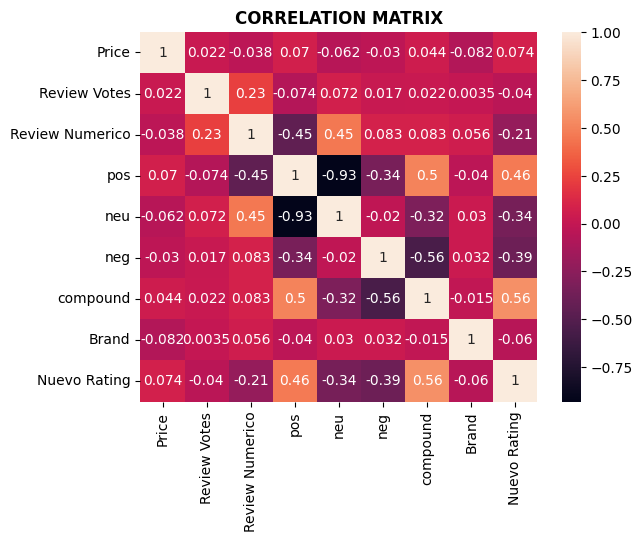

In [17]:
#Matiz de correlacion

plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title('CORRELATION MATRIX', fontweight='bold')
plt.show()
print("")

# Implementación de modelos 

Se implementarán modelos de clasificación de Decision Tree, Random Forest y Support Vector Machine para predecir si un producto tiene una review buena o mala. Por lo que se intentará predecir la columna 'Nuevo Rating'

In [18]:
X = df_combined[['Price', 'Review Numerico', 'Review Votes', 'neg', 'neu', 'pos', 'compound', 'Brand']]
y = df_combined['Nuevo Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("N° of row in X_train: ", X_train.shape[0])
print("N° of row in X_test: ", X_test.shape[0])
print("N° of row in y_train: ", y_train.shape[0])
print("N° of row in y_test: ", y_test.shape[0])

N° of row in X_train:  331016
N° of row in X_test:  82754
N° of row in y_train:  331016
N° of row in y_test:  82754


### Decision Tree - Manual


In [19]:
#Realizando el modelo Decision Tree Classifier de manera manual
dt_classifier = DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, random_state=42)
dt_classifier.fit(X_train, y_train)

# Predicciones
y_pred_dt_train = dt_classifier.predict(X_train)
y_pred_dt_test = dt_classifier.predict(X_test)

In [20]:
# Evaluación del entrenamiento
print("Resultados de Decision Tree en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_dt_train))

Resultados de Decision Tree en Entrenamiento:
Accuracy: 0.8622
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78    103058
           1       0.89      0.91      0.90    227958

    accuracy                           0.86    331016
   macro avg       0.84      0.84      0.84    331016
weighted avg       0.86      0.86      0.86    331016



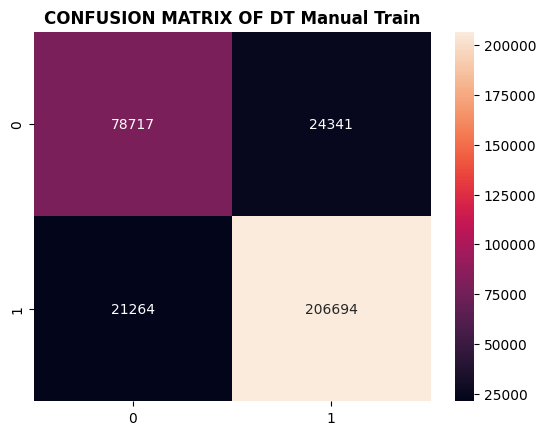

In [21]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_dt_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT Manual Train', fontweight='bold')
plt.show()

In [34]:
# Evaluación del test
print("Resultados de Decision Tree en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_test))

Resultados de Decision Tree en Test:
Accuracy: 0.8740
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80     25764
           1       0.91      0.91      0.91     56990

    accuracy                           0.87     82754
   macro avg       0.85      0.85      0.85     82754
weighted avg       0.87      0.87      0.87     82754



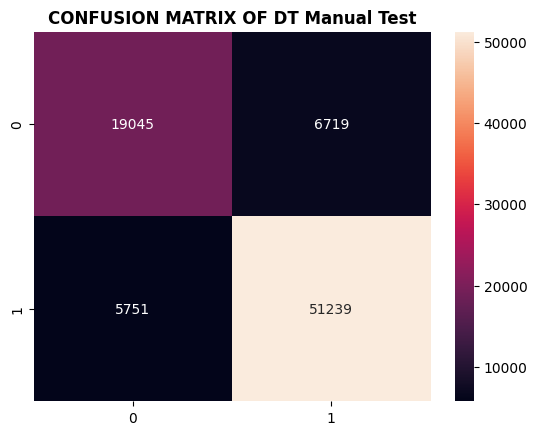

In [23]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_dt_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT Manual Test', fontweight='bold')
plt.show()

### Decision Tree - GridSearch

In [24]:
dt_classifier = DecisionTreeClassifier()
param_dt_classif = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [10, 12, 20],
    'min_samples_leaf': [5, 10, 15] 
}

grid_search_dt = GridSearchCV(estimator=dt_classifier, param_grid=param_dt_classif, cv=5, verbose=1)
grid_search_dt.fit(X_train, y_train)
best_class_dt = grid_search_dt.best_estimator_

best_class_dt

Fitting 5 folds for each of 27 candidates, totalling 135 fits


DecisionTreeClassifier(max_depth=20, min_samples_leaf=5)

In [25]:
# Predicciones
y_pred_dt_train = best_class_dt.predict(X_train)
y_pred_dt_test = best_class_dt.predict(X_test)

In [26]:
# Evaluación del entrenamiento
print("Resultados de Decision Tree en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_dt_train))

Resultados de Decision Tree en Entrenamiento:
Accuracy: 0.9213
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87    103058
           1       0.94      0.94      0.94    227958

    accuracy                           0.92    331016
   macro avg       0.91      0.91      0.91    331016
weighted avg       0.92      0.92      0.92    331016



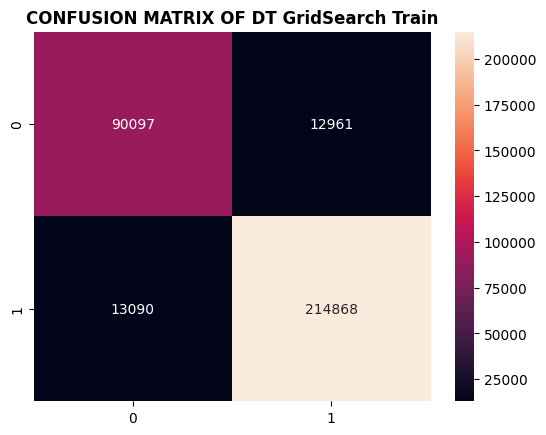

In [27]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_dt_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT GridSearch Train', fontweight='bold')
plt.show()

In [28]:
# Evaluación del test
print("Resultados de Decision Tree en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_test))

Resultados de Decision Tree en Test:
Accuracy: 0.8740
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80     25764
           1       0.91      0.91      0.91     56990

    accuracy                           0.87     82754
   macro avg       0.85      0.85      0.85     82754
weighted avg       0.87      0.87      0.87     82754



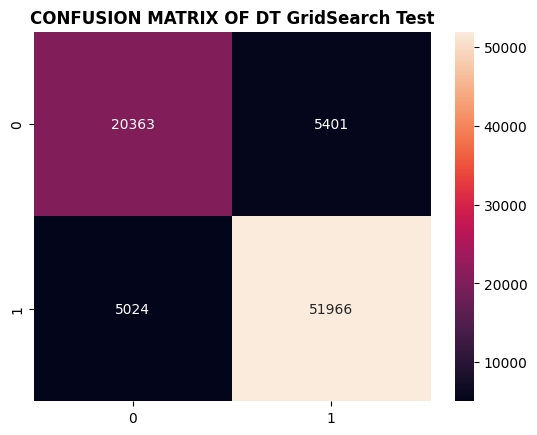

In [29]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_dt_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT GridSearch Test', fontweight='bold')
plt.show()

### Random Forest - Manual


In [ ]:
rf_classifier = RandomForestClassifier(max_depth=12, min_samples_leaf=10, random_state=42)
rf_classifier.fit(X_train, y_train)

# Predicciones
y_pred_rf_train = rf_classifier.predict(X_train)
y_pred_rf_test = rf_classifier.predict(X_test)

In [ ]:
# Evaluación del entrenamiento de Random Forest
print("Resultados de Random Forest en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_rf_train))

Resultados de Random Forest en Entrenamiento:
Accuracy: 0.8648
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78    103058
           1       0.89      0.91      0.90    227958

    accuracy                           0.86    331016
   macro avg       0.85      0.84      0.84    331016
weighted avg       0.86      0.86      0.86    331016



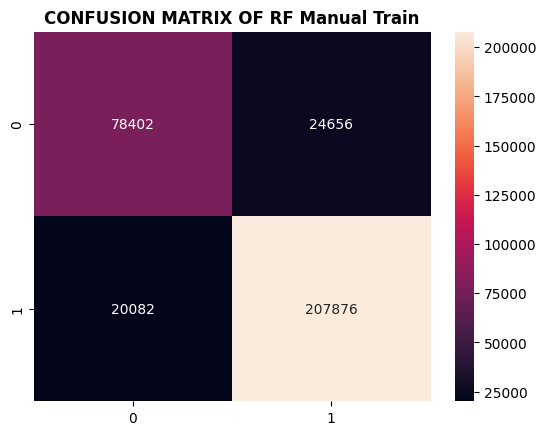

In [35]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_rf_train), annot=True, fmt='g') 
plt.title('CONFUSION MATRIX OF RF Manual Train', fontweight='bold')
plt.show()

In [ ]:
# Evaluación del test
print("Resultados de Random Forest en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_test))

Resultados de Random Forest en Test:
Accuracy: 0.8574
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76     25764
           1       0.89      0.91      0.90     56990

    accuracy                           0.86     82754
   macro avg       0.84      0.83      0.83     82754
weighted avg       0.86      0.86      0.86     82754



Text(0.5, 1.0, 'CONFUSION MATRIX OF RF Manual Test')

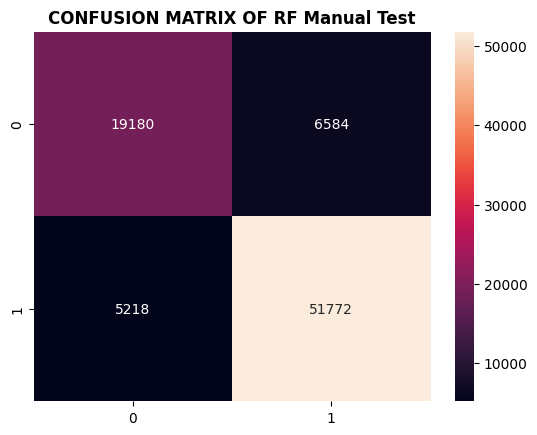

In [ ]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_rf_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF RF Manual Test', fontweight='bold')

### Random Forest - GridSearch

In [44]:
rf_classifier = RandomForestClassifier(random_state=42)
param_rf_classif = {
    'n_estimators': [100, 200],
    'max_depth': [10, 12, 20],
    'min_samples_leaf': [5, 10, 15]
}

grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_rf_classif, cv=5, verbose=1, n_jobs=-1)
grid_search_rf.fit(X_train, y_train)
best_class_rf = grid_search_rf.best_estimator_

best_class_rf

Fitting 5 folds for each of 18 candidates, totalling 90 fits


RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=200,
                       random_state=42)

In [45]:
# Predicciones
y_pred_rf_train = best_class_rf.predict(X_train)
y_pred_rf_test = best_class_rf.predict(X_test)

In [46]:
# Evaluación del entrenamiento
print("Resultados de Random Forest en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_rf_train))

Resultados de Random Forest en Entrenamiento:
Accuracy: 0.9280
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88    103058
           1       0.94      0.95      0.95    227958

    accuracy                           0.93    331016
   macro avg       0.92      0.91      0.92    331016
weighted avg       0.93      0.93      0.93    331016



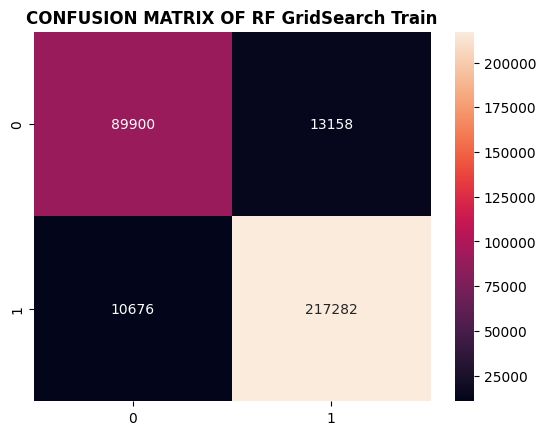

In [47]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_rf_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF RF GridSearch Train', fontweight='bold')
plt.show()

In [48]:
# Evaluación del test
print("Resultados de Random Forest en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_test))

Resultados de Random Forest en Test:
Accuracy: 0.8933
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.83     25764
           1       0.92      0.93      0.92     56990

    accuracy                           0.89     82754
   macro avg       0.88      0.87      0.87     82754
weighted avg       0.89      0.89      0.89     82754



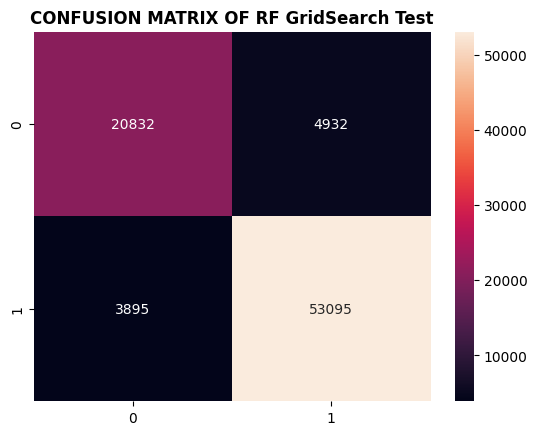

In [49]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_rf_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF RF GridSearch Test', fontweight='bold')
plt.show()

### SVC - Manual


In [50]:
svc_classifier = SVC(C=1.0, gamma='scale', kernel='rbf', random_state=42)
svc_classifier.fit(X_train_svc, y_train_svc)

# Predicciones
y_pred_svc_train = svc_classifier.predict(X_train_svc)
y_pred_svc_test = svc_classifier.predict(X_test_svc)

In [51]:
# Evaluación del entrenamiento de SVC
print("Resultados de SVC en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train_svc, y_pred_svc_train):.4f}")
print("Classification Report:")
print(classification_report(y_train_svc, y_pred_svc_train))

Resultados de SVC en Entrenamiento:
Accuracy: 0.8366
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.72      7442
           1       0.86      0.91      0.89     16558

    accuracy                           0.84     24000
   macro avg       0.82      0.79      0.80     24000
weighted avg       0.83      0.84      0.83     24000



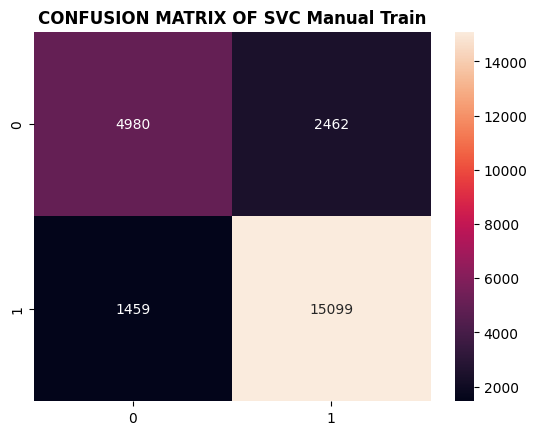

In [ ]:
plt.figure()
sns.heatmap(confusion_matrix(y_train_svc, y_pred_svc_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF SVC Manual Train', fontweight='bold')
plt.show()

In [53]:
# Evaluación del test
print("Resultados de SVC en Test:")
print(f"Accuracy: {accuracy_score(y_test_svc, y_pred_svc_test):.4f}")
print("Classification Report:")
print(classification_report(y_test_svc, y_pred_svc_test))

Resultados de SVC en Test:
Accuracy: 0.8348
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.71      1860
           1       0.86      0.91      0.88      4140

    accuracy                           0.83      6000
   macro avg       0.81      0.79      0.80      6000
weighted avg       0.83      0.83      0.83      6000



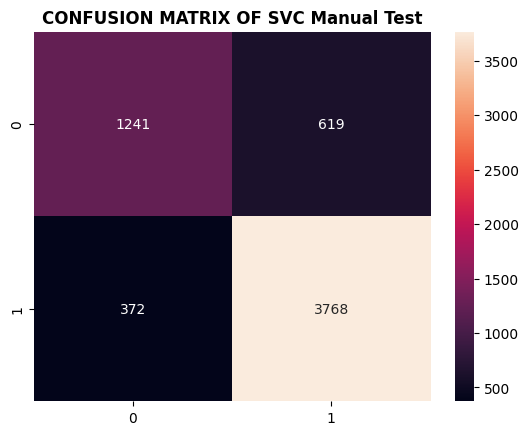

In [54]:
plt.figure()
sns.heatmap(confusion_matrix(y_test_svc, y_pred_svc_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF SVC Manual Test', fontweight='bold')
plt.show()

### Random Forest - GridSearch

In [55]:
svc_classifier_gs = SVC(random_state=42)
param_svc_classif = { # Parámetros ajustados para SVC
    'C': [0.1, 1, 10],  # Parámetro de regularización
    'gamma': ['scale', 0.1, 1], # Coeficiente del kernel
    'kernel': ['rbf']
}

grid_search_svc_gs = GridSearchCV(estimator=svc_classifier_gs, param_grid=param_svc_classif, cv=3, verbose=2, n_jobs=-1, scoring='accuracy') # cv=3 para reducir el tiempo de GS del SVC

print(f"Iniciando GridSearchCV para SVC en {len(X_train_svc)} muestras (escaladas)...")
grid_search_svc_gs.fit(X_train_svc, y_train_svc) # Usando datos ESCALADOS

best_class_svc = grid_search_svc_gs.best_estimator_

best_class_svc

Iniciando GridSearchCV para SVC en 24000 muestras (escaladas)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


SVC(C=10, gamma=0.1, random_state=42)

In [56]:
# Predicciones
y_pred_svc_train = best_class_svc.predict(X_train_svc)
y_pred_svc_test = best_class_svc.predict(X_test_svc)

In [ ]:
# Evaluación del entrenamiento
print("Resultados de SVC en Entrenamiento (GridSearchCV):")
print(f"Accuracy: {accuracy_score(y_train_svc, y_pred_svc_train):.4f}")
print("Classification Report:")
print(classification_report(y_train_svc, y_pred_svc_train))

Resultados de SVC en Entrenamiento (GridSearchCV):
Accuracy: 0.8396
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.68      0.73      7442
           1       0.86      0.91      0.89     16558

    accuracy                           0.84     24000
   macro avg       0.82      0.80      0.81     24000
weighted avg       0.84      0.84      0.84     24000



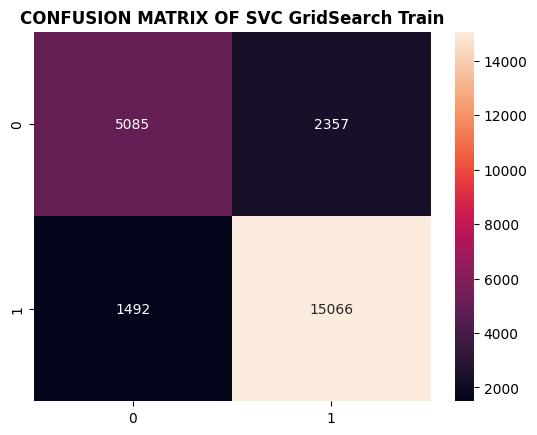

In [58]:
plt.figure()
sns.heatmap(confusion_matrix(y_train_svc, y_pred_svc_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF SVC GridSearch Train', fontweight='bold')
plt.show()

In [59]:
# Evaluación del test
print("Resultados de SVC en Test (GridSearchCV):")
print(f"Accuracy: {accuracy_score(y_test_svc, y_pred_svc_test):.4f}")
print("Classification Report:")
print(classification_report(y_test_svc, y_pred_svc_test))

Resultados de SVC en Test (GridSearchCV):
Accuracy: 0.8367
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72      1860
           1       0.86      0.91      0.88      4140

    accuracy                           0.84      6000
   macro avg       0.81      0.79      0.80      6000
weighted avg       0.83      0.84      0.83      6000



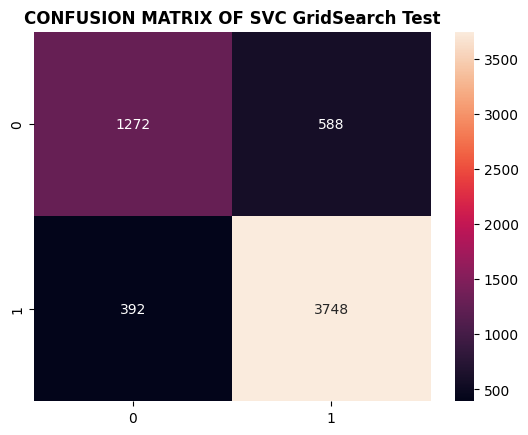

In [60]:
plt.figure()
sns.heatmap(confusion_matrix(y_test_svc, y_pred_svc_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF SVC GridSearch Test', fontweight='bold')
plt.show()